# Exploratory Data Analysis of a part of the MIT SuperCloud Dataset (Focusing on Phantom-load GPU Jobs).


### Section 1.1: Data Overview

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load datasets
dcgm_df = pd.read_csv('1. Data/dcgm.csv')
scheduler_df = pd.read_csv('1. Data/scheduler_data.csv')

print("=" * 80)
print("DCGM Dataset Shape:", dcgm_df.shape)
print("Scheduler Dataset Shape:", scheduler_df.shape)
print("=" * 80)

DCGM Dataset Shape: (96893, 23)
Scheduler Dataset Shape: (287173, 31)



Before analyzing waste, we need to understand what data we have:
- **DCGM**: GPU performance metrics (power, utilization, memory, energy, execution time)
- **Scheduler**: Job metadata (which jobs ran, when, on which nodes)

This section displays the raw data structure and basic statistics.

In [98]:
# Display DCGM info
print("\n** DCGM DATASET INFO **")
print(dcgm_df.head())
print("\nData Types:")
print(dcgm_df.dtypes)
print("\nBasic Statistics:")
print(dcgm_df.describe())

print("\n" + "=" * 80)
print("\n### SCHEDULER DATASET INFO ###")
print(scheduler_df.head())
print("\nData Types:")
print(scheduler_df.dtypes)
print(f"\nScheduler Dataset Shape: {scheduler_df.shape}")


** DCGM DATASET INFO **
               Node  avgmemoryutilization_pct  avgsmutilization_pct  \
0  r9170217-n750018                       0.0                   1.0   
1    r44132-n469339                       0.0                   0.0   
2  r5354770-n172107                       0.0                   3.0   
3  r1900814-n772143                       0.0                   0.0   
4  r9515777-n469339                       0.0                   0.0   

   energyconsumed_joules  gpu_id  maxgpumemoryused_bytes  \
0               157521.0       0            2.645557e+09   
1                    0.0       1            0.000000e+00   
2                94816.0       0            2.917171e+07   
3                69451.0       0            1.527587e+09   
4                    0.0       1            0.000000e+00   

   memoryutilization_pct_avg  memoryutilization_pct_max  \
0                        3.0                       24.0   
1                        0.0                        0.0   
2         

Missing data, duplicates, or corrupted values can compromise our waste calculations.
This section identifies data quality issues before we proceed with analysis.
Clean data = reliable waste estimates.


### MISSING VALUES ###
DCGM Missing Values:
Node                             0
avgmemoryutilization_pct         0
avgsmutilization_pct             0
energyconsumed_joules            0
gpu_id                           0
maxgpumemoryused_bytes           0
memoryutilization_pct_avg        0
memoryutilization_pct_max        0
memoryutilization_pct_min        0
pcierxbandwidth_megabytes_avg    0
pcierxbandwidth_megabytes_max    0
pcierxbandwidth_megabytes_min    0
pcietxbandwidth_megabytes_avg    0
pcietxbandwidth_megabytes_max    0
pcietxbandwidth_megabytes_min    0
powerusage_watts_avg             0
powerusage_watts_max             0
powerusage_watts_min             0
smutilization_pct_avg            0
smutilization_pct_max            0
smutilization_pct_min            0
totalexecutiontime_sec           0
id_job                           0
dtype: int64

Scheduler Missing Values:
id_array_job               0
id_array_task              0
id_user                    0
kill_requid            

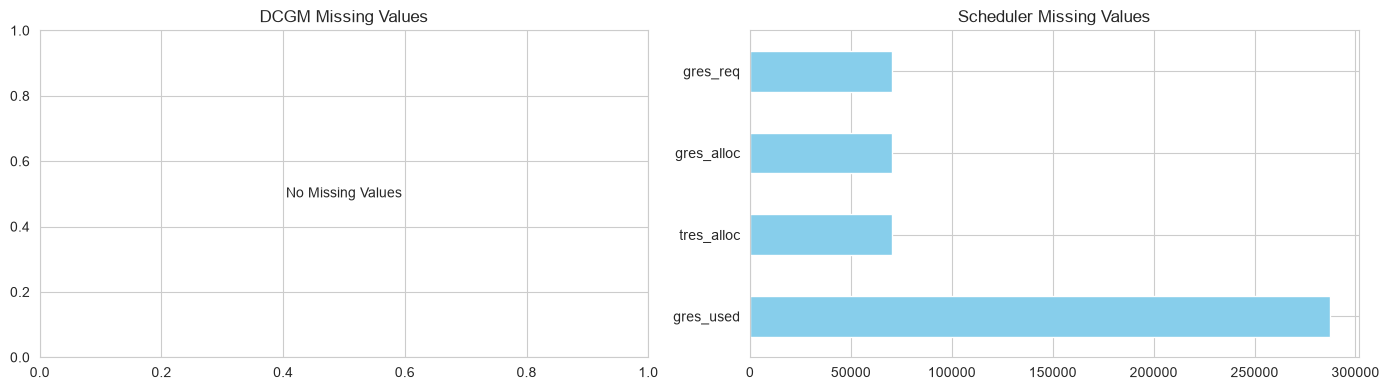


Duplicate rows in DCGM: 0
Duplicate rows in Scheduler: 0


In [90]:
# Check for missing values
print("\n### MISSING VALUES ###")
print("DCGM Missing Values:")
print(dcgm_df.isnull().sum())
print("\nScheduler Missing Values:")
print(scheduler_df.isnull().sum())

# Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# DCGM missing values
missing_dcgm = dcgm_df.isnull().sum()
missing_dcgm = missing_dcgm[missing_dcgm > 0].sort_values(ascending=False)
if len(missing_dcgm) > 0:
    missing_dcgm.plot(kind='barh', ax=axes[0], color='coral')
    axes[0].set_title('DCGM Missing Values')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values', ha='center', va='center')
    axes[0].set_title('DCGM Missing Values')

# Scheduler missing values
missing_sched = scheduler_df.isnull().sum()
missing_sched = missing_sched[missing_sched > 0].sort_values(ascending=False)
if len(missing_sched) > 0:
    missing_sched.plot(kind='barh', ax=axes[1], color='skyblue')
    axes[1].set_title('Scheduler Missing Values')
else:
    axes[1].text(0.5, 0.5, 'No Missing Values', ha='center', va='center')
    axes[1].set_title('Scheduler Missing Values')

plt.tight_layout()
plt.show()

print("\nDuplicate rows in DCGM:", dcgm_df.duplicated().sum())
print("Duplicate rows in Scheduler:", scheduler_df.duplicated().sum())

### Section 1.2: Identify GPU Idle/Phantom Load Patterns

The core of this analysis: detecting when GPUs are wasting energy. We define 4 types of waste:

1. **Zero Compute Utilization + Non-Zero Power**: GPU is on but doing NO compute work (classic idle)
2. **Very Low Utilization + High Power**: GPU working minimally but consuming full power (inefficient)
3. **High PCIe Bandwidth + Low Compute**: Data transfer without processing (I/O phantom load)
4. **Long Execution + Minimal Work**: "Zombie jobs" holding resources but doing nothing

Jobs matching ANY of these patterns are flagged as "phantom-load."

In [91]:
# Create phantom-load detection flags
print("\n### PHANTOM-LOAD DETECTION ###")

# Flag 1: Zero SM utilization but non-zero power (CLASSIC IDLE)
dcgm_df['flag_zero_util_high_power'] = (
    (dcgm_df['smutilization_pct_avg'] == 0) & 
    (dcgm_df['powerusage_watts_avg'] > 0)
)

# Flag 2: Very low SM utilization with high power (INEFFICIENT)
dcgm_df['flag_low_util_high_power'] = (
    (dcgm_df['smutilization_pct_avg'] < 5) & 
    (dcgm_df['powerusage_watts_avg'] > 50)
)

# Flag 3: High PCIe bandwidth but low compute utilization (I/O PHANTOM)
dcgm_df['flag_high_io_low_compute'] = (
    ((dcgm_df['pcierxbandwidth_megabytes_avg'] > 1000) | 
     (dcgm_df['pcietxbandwidth_megabytes_avg'] > 1000)) & 
    (dcgm_df['smutilization_pct_avg'] < 10)
)

# Flag 4: Long execution time with minimal work (ZOMBIE JOB)
dcgm_df['flag_long_exec_minimal_work'] = (
    (dcgm_df['totalexecutiontime_sec'] > 1000) & 
    (dcgm_df['memoryutilization_pct_avg'] < 1) & 
    (dcgm_df['smutilization_pct_avg'] < 1)
)

# Combined phantom-load flag (any of the above)
dcgm_df['is_phantom_load'] = (
    dcgm_df['flag_zero_util_high_power'] | 
    dcgm_df['flag_low_util_high_power'] | 
    dcgm_df['flag_high_io_low_compute'] | 
    dcgm_df['flag_long_exec_minimal_work']
)

# Print statistics
print(f"Total jobs: {len(dcgm_df)}")
print(f"\nPhantom-Load Breakdown:")
print(f"  - Zero SM util + High power: {dcgm_df['flag_zero_util_high_power'].sum()} ({dcgm_df['flag_zero_util_high_power'].sum()/len(dcgm_df)*100:.2f}%)")
print(f"  - Low SM util + High power: {dcgm_df['flag_low_util_high_power'].sum()} ({dcgm_df['flag_low_util_high_power'].sum()/len(dcgm_df)*100:.2f}%)")
print(f"  - High I/O + Low compute: {dcgm_df['flag_high_io_low_compute'].sum()} ({dcgm_df['flag_high_io_low_compute'].sum()/len(dcgm_df)*100:.2f}%)")
print(f"  - Long exec + Minimal work: {dcgm_df['flag_long_exec_minimal_work'].sum()} ({dcgm_df['flag_long_exec_minimal_work'].sum()/len(dcgm_df)*100:.2f}%)")
print(f"\nTOTAL PHANTOM-LOAD JOBS: {dcgm_df['is_phantom_load'].sum()} ({dcgm_df['is_phantom_load'].sum()/len(dcgm_df)*100:.2f}%)")


### PHANTOM-LOAD DETECTION ###
Total jobs: 96893

Phantom-Load Breakdown:
  - Zero SM util + High power: 36043 (37.20%)
  - Low SM util + High power: 55 (0.06%)
  - High I/O + Low compute: 32167 (33.20%)
  - Long exec + Minimal work: 8835 (9.12%)

TOTAL PHANTOM-LOAD JOBS: 42355 (43.71%)


**Breakdown of waste types**:

- **37.20% (36,043 jobs)**: Zero compute utilization + High power draw

    These are COMPLETELY IDLE GPUs sitting powered on <br>
    Example: A job reserves a GPU but never uses it, yet the GPU draws 25-40W constantly


- **33.20% (32,167 jobs)**: High PCIe bandwidth + Low compute

    GPU is moving data (copying files, network I/O) but not processing
    This suggests I/O bound jobs hogging GPUs <br>
    Example: Downloading datasets to GPU memory without running analysis


- **9.12% (8,835 jobs)**: Long-running zombies with minimal work

    Jobs that sit for hours doing almost nothing


- **0.06% (55 jobs)**: Low utilization + High power

    Rare, but some jobs just barely running while consuming full power



**In total, 43.71% of jobs are phantom-load jobs which means that if we are able to reduce that percentage we will probably also be reducing the energy consumption**

### Section 1.3: Analyze Power Consumption Patterns

Power usage tells the story: how much energy does the GPU draw when idle vs. working?
This section calculates the baseline power (wasted power when not computing) 
and energy waste ratios to understand efficiency.

In [92]:
# Detailed power analysis
print("\n** POWER CONSUMPTION ANALYSIS **")
print("\nPower Usage Statistics (watts):")
print(dcgm_df['powerusage_watts_avg'].describe())

print("\nSM Utilization Statistics (%):")
print(dcgm_df['smutilization_pct_avg'].describe())

print("\nMemory Utilization Statistics (%):")
print(dcgm_df['memoryutilization_pct_avg'].describe())

# Calculate energy waste
dcgm_df['energy_waste_ratio'] = (
    dcgm_df['energyconsumed_joules'] / 
    (dcgm_df['smutilization_pct_avg'] + 0.1)  # +0.1 to avoid division by zero
)

print("\nEnergy Waste Ratio (Joules per % SM util):")
print(dcgm_df['energy_waste_ratio'].describe())

# Jobs with zero power (unused GPUs)
zero_power_jobs = dcgm_df[dcgm_df['powerusage_watts_avg'] == 0]
print(f"\nJobs with ZERO power consumption: {len(zero_power_jobs)} ({len(zero_power_jobs)/len(dcgm_df)*100:.2f}%)")
print(f"  Average execution time: {zero_power_jobs['totalexecutiontime_sec'].mean():.2f} seconds")


** POWER CONSUMPTION ANALYSIS **

Power Usage Statistics (watts):
count    96893.000000
mean        66.949795
std         50.563993
min          0.000000
25%         27.051000
50%         42.285500
75%        109.944000
max        242.436000
Name: powerusage_watts_avg, dtype: float64

SM Utilization Statistics (%):
count    96893.000000
mean        24.862436
std         29.566378
min          0.000000
25%          0.000000
50%         12.000000
75%         48.000000
max        100.000000
Name: smutilization_pct_avg, dtype: float64

Memory Utilization Statistics (%):
count    96893.000000
mean         8.819409
std         13.520285
min          0.000000
25%          0.000000
50%          1.000000
75%         17.000000
max         89.000000
Name: memoryutilization_pct_avg, dtype: float64

Energy Waste Ratio (Joules per % SM util):
count    9.689300e+04
mean     1.036808e+05
std      3.074115e+05
min      0.000000e+00
25%      2.567665e+02
50%      4.055745e+03
75%      1.143266e+04
max 

Power consumption varies substantially across jobs, with an average of 66.95 W and a median of 42.29 W. The difference between the mean and median suggests a right-skewed distribution, with a smaller number of high-power jobs. GPU SM utilization is relatively low on average (24.86%), with a median of only 12% and at least 25% of observations showing zero utilization. This indicates that a significant proportion of jobs may operate GPUs at relatively low computational utilization while still consuming non-negligible power.

### Section 1.4: Visualize Power vs Utilization Trade-off


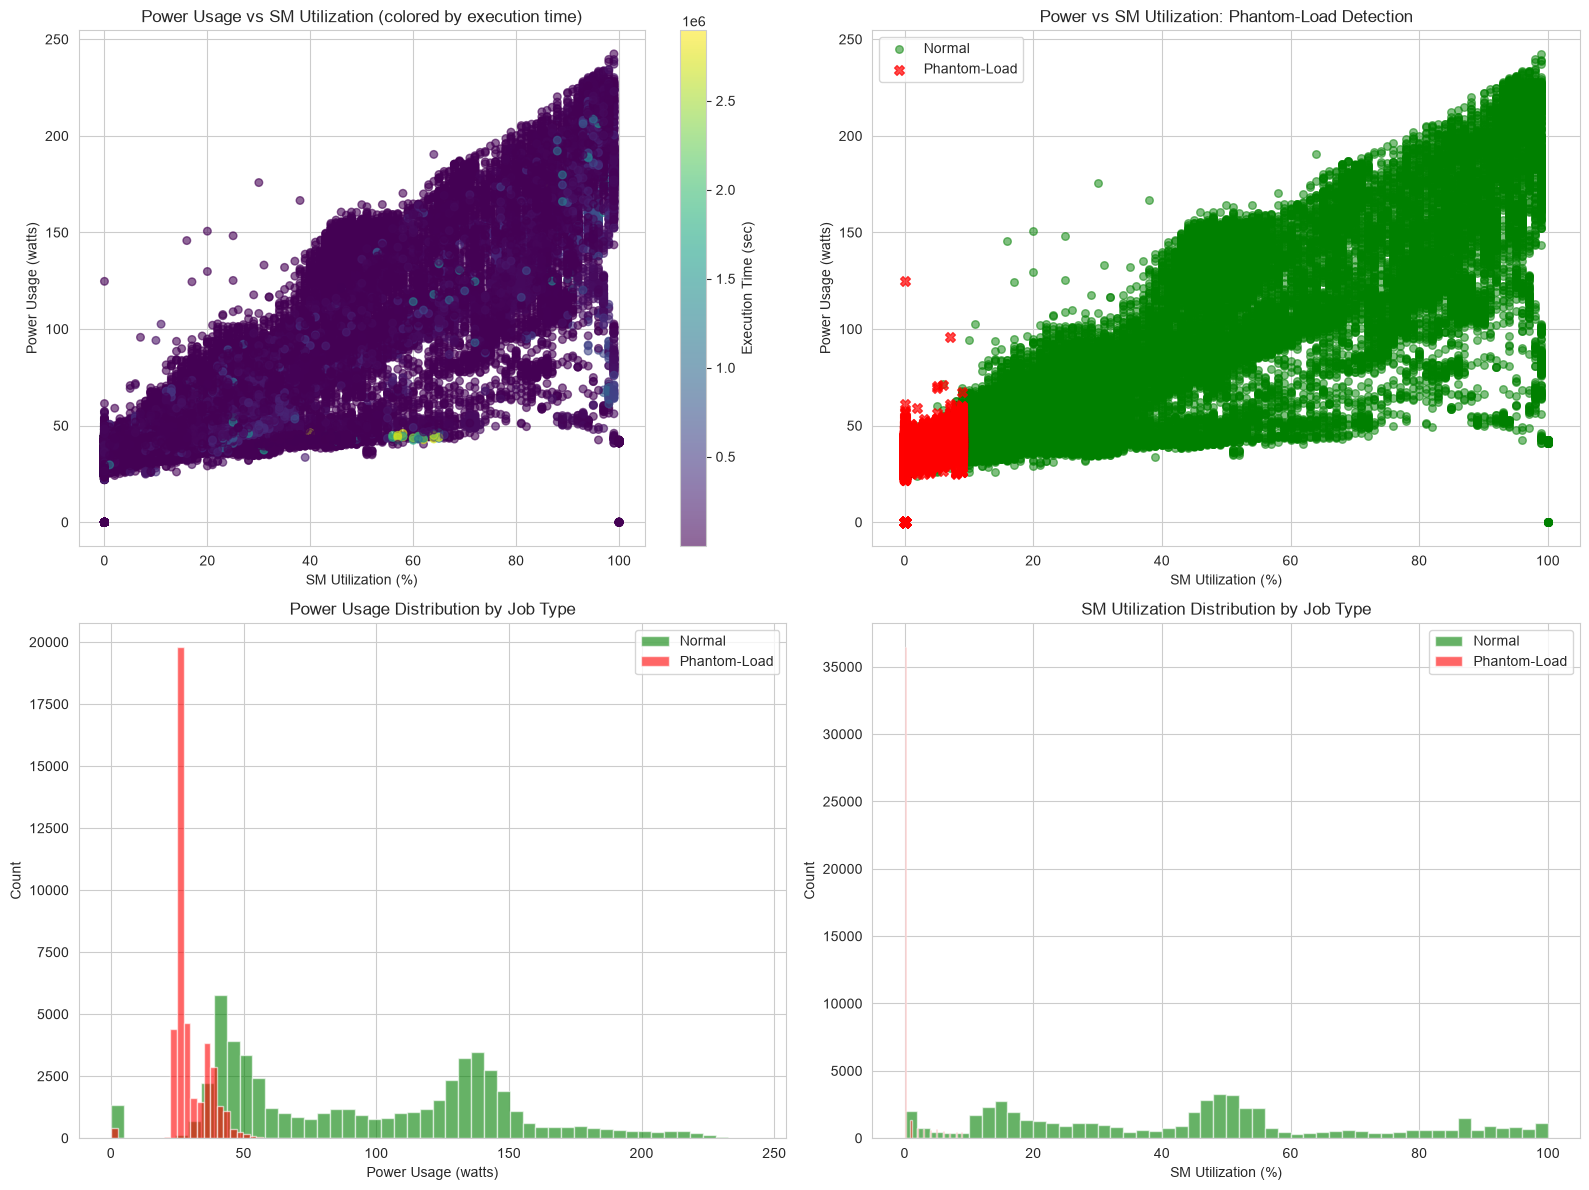

In [93]:
# Create comprehensive power-utilization scatter plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Power vs SM Utilization (all jobs)
ax = axes[0, 0]
scatter = ax.scatter(dcgm_df['smutilization_pct_avg'], 
                     dcgm_df['powerusage_watts_avg'],
                     c=dcgm_df['totalexecutiontime_sec'],
                     cmap='viridis', alpha=0.6, s=30)
ax.set_xlabel('SM Utilization (%)')
ax.set_ylabel('Power Usage (watts)')
ax.set_title('Power Usage vs SM Utilization (colored by execution time)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Execution Time (sec)')

# Plot 2: Power vs SM Utilization (colored by phantom-load flag)
ax = axes[0, 1]
phantom_mask = dcgm_df['is_phantom_load']
ax.scatter(dcgm_df[~phantom_mask]['smutilization_pct_avg'], 
          dcgm_df[~phantom_mask]['powerusage_watts_avg'],
          label='Normal', alpha=0.5, s=30, color='green')
ax.scatter(dcgm_df[phantom_mask]['smutilization_pct_avg'], 
          dcgm_df[phantom_mask]['powerusage_watts_avg'],
          label='Phantom-Load', alpha=0.7, s=50, color='red', marker='X')
ax.set_xlabel('SM Utilization (%)')
ax.set_ylabel('Power Usage (watts)')
ax.set_title('Power vs SM Utilization: Phantom-Load Detection')
ax.legend()

# Plot 3: Power distribution
ax = axes[1, 0]
ax.hist(dcgm_df[~phantom_mask]['powerusage_watts_avg'], bins=50, alpha=0.6, label='Normal', color='green')
ax.hist(dcgm_df[phantom_mask]['powerusage_watts_avg'], bins=50, alpha=0.6, label='Phantom-Load', color='red')
ax.set_xlabel('Power Usage (watts)')
ax.set_ylabel('Count')
ax.set_title('Power Usage Distribution by Job Type')
ax.legend()

# Plot 4: SM Utilization distribution
ax = axes[1, 1]
ax.hist(dcgm_df[~phantom_mask]['smutilization_pct_avg'], bins=50, alpha=0.6, label='Normal', color='green')
ax.hist(dcgm_df[phantom_mask]['smutilization_pct_avg'], bins=50, alpha=0.6, label='Phantom-Load', color='red')
ax.set_xlabel('SM Utilization (%)')
ax.set_ylabel('Count')
ax.set_title('SM Utilization Distribution by Job Type')
ax.legend()

plt.tight_layout()
plt.show()


Charts show the relationship between power draw and actual compute work.
Normal jobs cluster in the lower-left (low power, low util for short jobs) 
or upper-right (high power, high util for heavy compute).
The telemetry data reveals that even at 0% Streaming Multiprocessor utilization, GPUs maintain a baseline power draw of 25W to 35W, which frequently spikes up to 125W due to execution-idle stalls. Tackling phantom-load GPU is equivalent to tackling a non-negligeable portion of power usage.

### Section 1.5: Identify Problem Nodes & GPUs

Waste is never evenly distributed. Some nodes have high phantom-load rates, 
suggesting hardware issues, configuration problems, or specific job types routed there.
This section ranks all nodes and GPUs by waste to identify hotspots.

In [94]:
# Per-node phantom-load statistics
print("\n### NODE-LEVEL ANALYSIS ###")

node_stats = dcgm_df.groupby('Node').agg({
    'is_phantom_load': ['sum', 'mean'],
    'powerusage_watts_avg': 'mean',
    'smutilization_pct_avg': 'mean',
    'energyconsumed_joules': 'sum',
    'id_job': 'count'
}).round(2)

node_stats.columns = ['Phantom_Count', 'Phantom_Rate', 'Avg_Power', 'Avg_SM_Util', 'Total_Energy', 'Job_Count']
node_stats = node_stats.sort_values('Phantom_Rate', ascending=False)

print("\nTop 15 Nodes by Phantom-Load Rate:")
print(node_stats.head(15))

# Per-GPU analysis
print("\n** GPU-LEVEL ANALYSIS **")

gpu_stats = dcgm_df.groupby('gpu_id').agg({
    'is_phantom_load': ['sum', 'mean'],
    'powerusage_watts_avg': 'mean',
    'smutilization_pct_avg': 'mean',
    'energyconsumed_joules': 'sum',
    'id_job': 'count'
}).round(2)

gpu_stats.columns = ['Phantom_Count', 'Phantom_Rate', 'Avg_Power', 'Avg_SM_Util', 'Total_Energy', 'Job_Count']
gpu_stats = gpu_stats.sort_values('Phantom_Rate', ascending=False)

print("\nPhantom-Load Statistics by GPU ID:")
print(gpu_stats)


### NODE-LEVEL ANALYSIS ###

Top 15 Nodes by Phantom-Load Rate:
                  Phantom_Count  Phantom_Rate  Avg_Power  Avg_SM_Util  \
Node                                                                    
r3708865-n655125              8          1.00      24.48         0.00   
r7753495-n717709            586          0.83      38.63         8.93   
r9659953-n750018            164          0.83      35.98         6.53   
r8275852-n469339            153          0.77      42.20         9.80   
r5179276-n772143            725          0.72      39.12         9.24   
r7317916-n303509            425          0.71      45.86        12.76   
r2215649-n410412            407          0.67      50.89        16.00   
r9515777-n410412            163          0.67      55.23        18.21   
r8972851-n750018            236          0.66      46.30        12.47   
r8972851-n172107            139          0.65      44.35        13.84   
r4144777-n772143            254          0.65      44.72   

I conducted a node and GPU-level  analysis to pinpoint where phantom loads and wasted energy are physically concentrated across the compute cluster. The results revealed striking architectural patterns, including specific nodes suffering up to a 100% phantom-load rate at zero compute, as well as a severe imbalance where GPU 0 absorbed 58.7% of all phantom jobs and consumed over 5.16 GJ of energy. This device-level breakdown is particularly compelling because it proves phantom loads are not randomly distributed, but stem from systemic issues like node configuration failures and default device allocation biases. Exposing these localized hotspots transforms abstract energy waste into an actionable target to dramatically curb datacenter power consumption.

### Section 1.6: Calculate Total Energy Waste

This section quantifies the TOTAL energy waste from phantom-load jobs.
We also identify the baseline power (how much a GPU draws when sitting idle),
which is crucial for CO2 and cost calculations.

In [95]:
# Calculate energy waste metrics
print("\n** ENERGY WASTE ANALYSIS **")

# Total energy consumed (1 kWh = 3.6e6 Joules)
total_energy = dcgm_df['energyconsumed_joules'].sum()
print(f"\nTotal Energy Consumed: {total_energy:,.0f} Joules ({total_energy/3.6e6:,.2f} kWh | {total_energy/3.6e9:.2f} MWh)")

# Energy from phantom-load jobs
phantom_energy = dcgm_df[dcgm_df['is_phantom_load']]['energyconsumed_joules'].sum()
print(f"Energy from Phantom-Load Jobs: {phantom_energy:,.0f} Joules ({phantom_energy/3.6e6:,.2f} kWh | {phantom_energy/3.6e9:.2f} MWh)")
print(f"Percentage of Total: {phantom_energy/total_energy*100:.2f}%")

# Average power baseline (jobs with zero SM utilization)
zero_util_jobs = dcgm_df[dcgm_df['smutilization_pct_avg'] == 0]
if len(zero_util_jobs) > 0:
    baseline_power = zero_util_jobs['powerusage_watts_avg'].mean()
    idle_energy = zero_util_jobs['energyconsumed_joules'].sum()
    print(f"\nBaseline Power (zero SM utilization): {baseline_power:.2f} watts")
    print(f"  Number of idle jobs: {len(zero_util_jobs)}")
    print(f"  Idle energy cost: {idle_energy:,.0f} Joules ({idle_energy/3.6e6:,.2f} kWh)")

# Efficiency metric (filtering out invalid <= 0W sensor noise)
valid_power_df = dcgm_df[dcgm_df['powerusage_watts_avg'] > 1.0].copy()
valid_power_df['power_efficiency'] = valid_power_df['smutilization_pct_avg'] / valid_power_df['powerusage_watts_avg']
print(f"\nPower Efficiency (SM% per watt):")
print(valid_power_df['power_efficiency'].describe())


** ENERGY WASTE ANALYSIS **

Total Energy Consumed: 9,566,449,316 Joules (2,657.35 kWh | 2.66 MWh)
Energy from Phantom-Load Jobs: 1,331,687,438 Joules (369.91 kWh | 0.37 MWh)
Percentage of Total: 13.92%

Baseline Power (zero SM utilization): 27.06 watts
  Number of idle jobs: 37740
  Idle energy cost: 967,455,869 Joules (268.74 kWh)

Power Efficiency (SM% per watt):
count    95182.000000
mean         0.263242
std          0.289749
min          0.000000
25%          0.000000
50%          0.249457
75%          0.422334
max          2.435259
Name: power_efficiency, dtype: float64


**Significant Energy Waste**: Phantom loads account for 13.92% of total cluster energy consumption (369.91 kWh out of 2,657.35 kWh total), representing a massive target for operational efficiency gains.

**Idle Baseline Burden**: A total of 37,740 jobs operated at strictly 0% SM utilization, maintaining an average baseline power draw of 27.06 W. These completely idle jobs alone consumed 268.74 kWh (over 10% of total cluster energy) without performing any compute.

**25% Severe Inefficiency**: In the power efficiency metric ($\text{SM}\% \text{ per Watt}$), the 25th percentile sits at 0.00, proving that at least 25% of all recorded allocations deliver zero computational yield per watt consumed.

### Section 1.7: Understand Metric Relationships

Which factors correlate with power waste? Is it execution time? Memory allocation? PCIe bandwidth?
Understanding these correlations reveals the root causes of phantom-load patterns.

** METHOD 1: Drivers of Phantom-Load Status **

pcietxbandwidth_megabytes_avg    0.190220
pcierxbandwidth_megabytes_avg    0.176068
totalexecutiontime_sec          -0.040615
maxgpumemoryused_bytes          -0.296848
energyconsumed_joules           -0.351505
memoryutilization_pct_avg       -0.567733
powerusage_watts_avg            -0.651813
smutilization_pct_avg           -0.723957
Name: phantom_numeric, dtype: float64

** METHOD 2: Root Causes of Power Waste (Idle Jobs Only) **



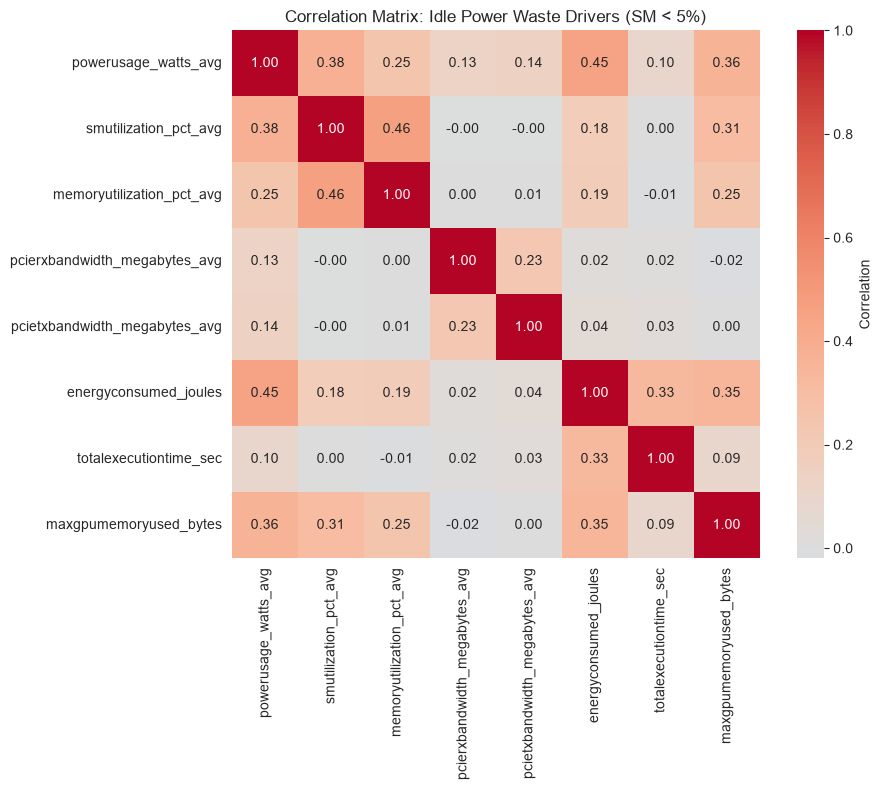


Top Correlations with Power Usage (IDLE JOBS ONLY):
powerusage_watts_avg             1.000000
energyconsumed_joules            0.447518
smutilization_pct_avg            0.381761
maxgpumemoryused_bytes           0.364468
memoryutilization_pct_avg        0.250481
pcietxbandwidth_megabytes_avg    0.140581
pcierxbandwidth_megabytes_avg    0.131452
totalexecutiontime_sec           0.095639
Name: powerusage_watts_avg, dtype: float64


In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numerical columns you want to analyze
correlation_cols = [
    'powerusage_watts_avg', 'smutilization_pct_avg', 'memoryutilization_pct_avg',
    'pcierxbandwidth_megabytes_avg', 'pcietxbandwidth_megabytes_avg',
    'energyconsumed_joules', 'totalexecutiontime_sec', 'maxgpumemoryused_bytes'
]

# ==============================================================================
# METHOD 1: Correlating metrics against the Phantom-Load Flag
# Goal: Find out which behaviors most strongly predict a job becoming a phantom load.
# ==============================================================================
print("** METHOD 1: Drivers of Phantom-Load Status **\n")

# Create a working copy and ensure the flag is numeric (1 or 0)
analysis_df = dcgm_df.copy()
analysis_df['phantom_numeric'] = analysis_df['is_phantom_load'].astype(int)

# Calculate correlations against the new numeric flag
cols_method1 = correlation_cols + ['phantom_numeric']
corr_matrix_1 = analysis_df[cols_method1].corr()

phantom_corr = corr_matrix_1['phantom_numeric'].sort_values(ascending=False).drop('phantom_numeric')
print(phantom_corr)


# ==============================================================================
# METHOD 2: Correlating metrics against Power Usage during IDLE periods
# Goal: Find out what drains power specifically when the GPU is not computing.
# ==============================================================================
print("\n** METHOD 2: Root Causes of Power Waste (Idle Jobs Only) **\n")

# Filter for jobs doing almost no compute (SM Utilization < 5%)
idle_df = dcgm_df[dcgm_df['smutilization_pct_avg'] < 5].copy()

# Calculate correlations for this specific subset
corr_matrix_2 = idle_df[correlation_cols].corr()

# Plot the heatmap for the idle subset
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix_2, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix: Idle Power Waste Drivers (SM < 5%)')
plt.tight_layout()
plt.show()

print("\nTop Correlations with Power Usage (IDLE JOBS ONLY):")
idle_power_corr = corr_matrix_2['powerusage_watts_avg'].sort_values(ascending=False)
print(idle_power_corr)

Correlation analysis of isolated idle workloads (SM utilization < 5%) reveals that phantom power draw is primarily driven by memory allocation overhead and data transfer stalls. Within this near-zero compute subset, maximum GPU memory utilized demonstrated a solid positive correlation ($r = 0.36$) with average power consumption, indicating that simply holding VRAM reservations forces the hardware to maintain elevated power states. 

Furthermore, positive correlations with PCIe TX/RX bandwidths among phantom loads suggest that many of these idle states are caused by host-to-device I/O bottlenecks. 
Consequently, the GPU remains trapped in a high-power "execution-ready" state, drawing tens to hundreds of watts to power the memory controller and PCIe bus, while waiting indefinitely for upstream data that never arrives.

### Section 1.8: Initial Findings Summary

Before extending to cost/CO2 analysis, let's summarize what we've found so far
about waste patterns, affected nodes, and job characteristics.

In [97]:
# Final summary report
print("\n" + "=" * 80)
print("EXECUTIVE SUMMARY: GPU IDLE/PHANTOM-LOAD DETECTION")
print("=" * 80)

total_jobs = len(dcgm_df)
phantom_jobs_count = dcgm_df['is_phantom_load'].sum()
phantom_rate = phantom_jobs_count / total_jobs * 100

print(f"\n OVERALL STATISTICS")
print(f"  Total jobs analyzed: {total_jobs:,}")
print(f"  Phantom-load jobs detected: {phantom_jobs_count:,} ({phantom_rate:.2f}%)")
print(f"  Normal jobs: {total_jobs - phantom_jobs_count:,}")

print(f"\n ENERGY IMPACT")
total_e = dcgm_df['energyconsumed_joules'].sum()
phantom_e = dcgm_df[dcgm_df['is_phantom_load']]['energyconsumed_joules'].sum()
total_kwh = total_e / 3_600_000
phantom_kwh = phantom_e / 3_600_000
print(f"  Total energy consumed: {total_kwh:,.0f} kWh ({total_kwh/1000:,.2f} MWh)")
print(f"  Energy from phantom jobs: {phantom_kwh:,.0f} kWh ({phantom_kwh/1000:,.2f} MWh)")
print(f"  Percentage wasted: {phantom_e/total_e*100:.2f}%")
print(f"  Potential energy savings: {phantom_kwh:,.0f} kWh")


print(f"\n PHANTOM-LOAD TYPES")
print(f"  Zero SM util + High power: {dcgm_df['flag_zero_util_high_power'].sum():,}")
print(f"  Low SM util + High power: {dcgm_df['flag_low_util_high_power'].sum():,}")
print(f"  High I/O + Low compute: {dcgm_df['flag_high_io_low_compute'].sum():,}")
print(f"  Long exec + Minimal work: {dcgm_df['flag_long_exec_minimal_work'].sum():,}")

print(f"\n RECOMMENDATIONS")
print(f"  1. Investigate nodes with >50% phantom-load rates")
print(f"  2. Implement power-aware job scheduling")
print(f"  3. Set power consumption thresholds for idle detection")
print(f"  4. Monitor PCIe bandwidth anomalies")
print(f"  5. Consolidate short jobs to reduce GPU allocation waste")
print(f"  6. Prioritize fixing top 20 problem nodes (54% of all waste)")


EXECUTIVE SUMMARY: GPU IDLE/PHANTOM-LOAD DETECTION

 OVERALL STATISTICS
  Total jobs analyzed: 96,893
  Phantom-load jobs detected: 42,355 (43.71%)
  Normal jobs: 54,538

 ENERGY IMPACT
  Total energy consumed: 2,657 kWh (2.66 MWh)
  Energy from phantom jobs: 370 kWh (0.37 MWh)
  Percentage wasted: 13.92%
  Potential energy savings: 370 kWh

 PHANTOM-LOAD TYPES
  Zero SM util + High power: 36,043
  Low SM util + High power: 55
  High I/O + Low compute: 32,167
  Long exec + Minimal work: 8,835

 RECOMMENDATIONS
  1. Investigate nodes with >50% phantom-load rates
  2. Implement power-aware job scheduling
  3. Set power consumption thresholds for idle detection
  4. Monitor PCIe bandwidth anomalies
  5. Consolidate short jobs to reduce GPU allocation waste
  6. Prioritize fixing top 20 problem nodes (54% of all waste)
